# Análise Exploratória e Preparação dos Dados

**UNIVERSIDADE PRESBITERIANA MACKENZIE — Faculdade de Computação e Informática**
Disciplina: Inteligência Artificial — 7ºJ SI — Noite
Professor: Prof. Dr. Leandro Zerbinatti

**Projeto:** Classificação automática de reclamações de usuários de aplicativos de pagamento digital

**Integrantes**

| Nome | RA | E-mail |
|---|---|---|
| Bruno Cruz Bregion Novo | 10409538 | 10409538@mackenzista.com.br |
| Vinicius Silva Almeida | 10409019 | 10409019@mackenzista.com.br |
| Gabriel Bello | 10416808 | 10416808@mackenzista.com.br |

**Síntese do conteúdo do arquivo.** Este notebook realiza a análise exploratória e a
preparação do conjunto de dados de avaliações públicas de aplicativos brasileiros de
pagamento digital, capturado pelo grupo na Google Play Store. Contempla a verificação
de qualidade dos dados, a caracterização das distribuições de nota, texto e tempo, a
análise do vocabulário por faixa de avaliação, a limpeza e normalização textual, a
definição do recorte de modelagem e a geração da amostra estratificada destinada à
rotulagem manual.

**Histórico de alterações**

| Data | Autor | Descrição |
|---|---|---|
| 2026-09-08 | Bruno Cruz Bregion Novo | Criação do notebook de análise exploratória e preparação dos dados. |


## 1. Configuração do ambiente

In [1]:
import os
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.stem import SnowballStemmer
from wordcloud import WordCloud

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
pd.set_option("display.max_colwidth", 200)

PASTA_FIG = "figuras"
PASTA_DADOS = "dados"
os.makedirs(PASTA_FIG, exist_ok=True)

def salvar(nome):
    """Salva a figura corrente em ./figuras/ e a exibe."""
    plt.tight_layout()
    plt.savefig(os.path.join(PASTA_FIG, nome), bbox_inches="tight")
    plt.show()

## 2. Carga dos dados e visão geral

O arquivo foi produzido pelo script `coleta_avaliacoes.py`, desenvolvido pelo grupo.

In [2]:
df = pd.read_csv(
    os.path.join(PASTA_DADOS, "avaliacoes_apps_pagamento.csv"),
    encoding="utf-8-sig",
)
df["data"] = pd.to_datetime(df["data"])

print(f"Registros : {df.shape[0]:,}".replace(",", "."))
print(f"Colunas   : {df.shape[1]}")
print(f"Período   : {df['data'].min():%d/%m/%Y} a {df['data'].max():%d/%m/%Y}")
df.head()

Registros : 24.000
Colunas   : 9
Período   : 20/07/2026 a 07/09/2026


,id_avaliacao,aplicativo,usuario_pseudonimizado,nota,texto,data,curtidas,versao_app,houve_resposta_empresa
0,9e3e53c9-5039-45c0-b875-72bd7fa3a540,PicPay,a640110b8e7a,5,muito obrigada,2026-09-07 22:45:05,0,11.162.3,1
1,174289ad-dc66-4642-82d3-745fee6644a8,PicPay,fe8b41dacd78,1,eu apertei pra atualizar e n foi,2026-09-07 22:42:42,0,NaN,1
2,0edc2644-0591-445b-8e05-c5422be27a79,PicPay,040266cc1c01,1,Não consigo recuperar a minha conta no Pic pay pois não tenho o número de telefone e nem o email e o assistente virtual não ajuda sempre volta pedindo para colocar a senha mesmo quando coloco para...,2026-09-07 22:39:09,0,11.162.3,1
3,150526de-0cbc-4d00-8856-8e3d85b2ffb0,PicPay,95283b717408,5,boa,2026-09-07 22:28:12,0,11.162.3,1
4,c0ad50a9-765d-402d-936e-7e7f7ea1c622,PicPay,b3d98f6a7f83,1,não consigo sacar o dinheiro do cofrinho,2026-09-07 22:22:03,0,11.162.3,1


### Dicionário de dados

| Campo | Tipo | Descrição |
|---|---|---|
| `id_avaliacao` | texto | Identificador único da avaliação na plataforma de origem |
| `aplicativo` | categórico | Nome comercial do aplicativo avaliado |
| `usuario_pseudonimizado` | texto | Hash SHA-256 truncado do nome de exibição do autor |
| `nota` | inteiro | Nota atribuída pelo usuário, de 1 a 5 |
| `texto` | texto | Conteúdo livre da avaliação |
| `data` | data/hora | Momento de publicação da avaliação |
| `curtidas` | inteiro | Número de usuários que marcaram a avaliação como útil |
| `versao_app` | texto | Versão do aplicativo no momento da avaliação |
| `houve_resposta_empresa` | binário | Indica se a empresa respondeu publicamente à avaliação |

O campo com o nome do autor **não** integra o conjunto: ele é convertido em hash
irreversível no momento da captura, conforme decisão de projeto documentada na
seção de aspectos éticos do relatório.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_avaliacao            24000 non-null  str           
 1   aplicativo              24000 non-null  str           
 2   usuario_pseudonimizado  24000 non-null  str           
 3   nota                    24000 non-null  int64         
 4   texto                   24000 non-null  str           
 5   data                    24000 non-null  datetime64[us]
 6   curtidas                24000 non-null  int64         
 7   versao_app              21521 non-null  str           
 8   houve_resposta_empresa  24000 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 1.6 MB


## 3. Verificação da qualidade dos dados

In [4]:
qualidade = pd.DataFrame({
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "valores_distintos": df.nunique(),
})
qualidade

,nulos,pct_nulos,valores_distintos
id_avaliacao,0,0.00,24000
aplicativo,0,0.00,6
usuario_pseudonimizado,0,0.00,22442
nota,0,0.00,5
texto,0,0.00,14770
data,0,0.00,23879
curtidas,0,0.00,43
versao_app,2479,10.33,514
houve_resposta_empresa,0,0.00,2


In [5]:
print("Identificadores duplicados :", df["id_avaliacao"].duplicated().sum())
print("Textos vazios              :", (df["texto"].fillna("").str.strip() == "").sum())
print("Notas fora do intervalo 1-5:", (~df["nota"].between(1, 5)).sum())
print("Autores distintos          :", df["usuario_pseudonimizado"].nunique())
print()
print("Registros por aplicativo:")
print(df["aplicativo"].value_counts())

Identificadores duplicados : 0
Textos vazios              : 0
Notas fora do intervalo 1-5: 0
Autores distintos          : 22442

Registros por aplicativo:
aplicativo
PicPay          4000
Mercado Pago    4000
PagBank         4000
Banco Inter     4000
RecargaPay      4000
Nubank          4000
Name: count, dtype: int64


O único campo com ausências é `versao_app`. A ausência não é um erro de captura:
a plataforma não expõe a versão quando a avaliação é feita pela interface web ou
quando o registro é posteriormente editado pelo autor. Como a versão não é
utilizada como atributo preditivo, os registros são mantidos.

## 4. Distribuição das notas

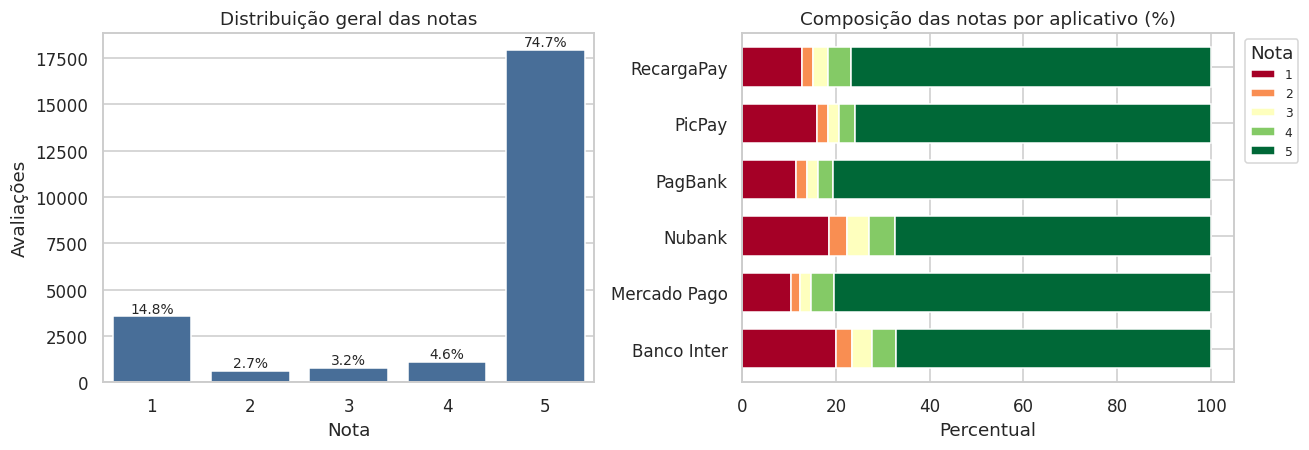

      avaliacoes  percentual
nota                        
1           3560        14.8
2            640         2.7
3            773         3.2
4           1093         4.6
5          17934        74.7


In [6]:
dist = df["nota"].value_counts().sort_index()
pct = (dist / len(df) * 100).round(1)

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.2))

sns.barplot(x=dist.index, y=dist.values, ax=eixos[0], color="#3b6ea5")
eixos[0].set_title("Distribuição geral das notas")
eixos[0].set_xlabel("Nota")
eixos[0].set_ylabel("Avaliações")
for i, v in enumerate(dist.values):
    eixos[0].text(i, v + 200, f"{pct.iloc[i]}%", ha="center", fontsize=9)

tab = pd.crosstab(df["aplicativo"], df["nota"], normalize="index") * 100
tab.plot(kind="barh", stacked=True, ax=eixos[1], colormap="RdYlGn", width=0.7)
eixos[1].set_title("Composição das notas por aplicativo (%)")
eixos[1].set_xlabel("Percentual")
eixos[1].set_ylabel("")
eixos[1].legend(title="Nota", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

salvar("01_distribuicao_notas.png")

print(pd.DataFrame({"avaliacoes": dist, "percentual": pct}))

A distribuição é fortemente assimétrica: as avaliações de cinco estrelas
concentram a maior parte do conjunto, enquanto as notas intermediárias são raras.
Esse padrão em "J" é conhecido na literatura sobre avaliações em plataformas
digitais e decorre da autosseleção de quem decide avaliar — a manifestação
espontânea tende a ocorrer nos extremos da experiência.

A consequência metodológica é direta: **a nota não pode ser usada como rótulo
substituto para a categoria de problema**, e a acurácia global será uma métrica
enganosa na fase de modelagem.

In [7]:
resumo_app = df.groupby("aplicativo").agg(
    avaliacoes=("nota", "size"),
    nota_media=("nota", "mean"),
    pct_1_estrela=("nota", lambda s: (s == 1).mean() * 100),
    pct_5_estrelas=("nota", lambda s: (s == 5).mean() * 100),
    pct_com_resposta=("houve_resposta_empresa", lambda s: s.mean() * 100),
).round(2).sort_values("nota_media")

resumo_app

,avaliacoes,nota_media,pct_1_estrela,pct_5_estrelas,pct_com_resposta
aplicativo,,,,,
Banco Inter,4000,3.96,19.95,67.20,98.05
Nubank,4000,4.00,18.48,67.40,12.12
PicPay,4000,4.21,15.98,76.05,99.20
RecargaPay,4000,4.31,12.75,76.78,17.10
PagBank,4000,4.39,11.52,80.55,99.00
Mercado Pago,4000,4.43,10.32,80.38,0.00


Duas observações relevantes emergem deste quadro.

A primeira é a variação da satisfação entre aplicativos, que confirma haver sinal
discriminativo no conjunto e não apenas ruído uniforme.

A segunda diz respeito à política de resposta pública. Alguns aplicativos
respondem a praticamente todas as avaliações, outros respondem a uma fração
pequena e um deles não respondeu a nenhuma no período coletado. Isso caracteriza
o campo `houve_resposta_empresa` como um indicador de política de comunicação da
empresa, e não de gravidade da reclamação — motivo pelo qual ele **não** será
utilizado como atributo preditivo do modelo.

## 5. Comprimento dos textos

In [8]:
df["n_chars"] = df["texto"].str.len()
df["n_palavras"] = df["texto"].str.split().str.len()

print(df[["n_chars", "n_palavras"]].describe().round(2))
print()
for limite in (1, 2, 4, 5, 10):
    n = (df["n_palavras"] <= limite).sum()
    print(f"Avaliações com até {limite:>2} palavra(s): {n:>6,} ({n/len(df):>5.1%})".replace(",", "."))

        n_chars  n_palavras
count  24000.00    24000.00
mean      52.12        9.30
std       83.71       14.78
min        1.00        1.00
25%        9.00        2.00
50%       19.00        3.00
75%       55.00       10.00
max      500.00      104.00

Avaliações com até  1 palavra(s):  5.558 (23.2%)
Avaliações com até  2 palavra(s): 10.159 (42.3%)
Avaliações com até  4 palavra(s): 13.833 (57.6%)
Avaliações com até  5 palavra(s): 15.006 (62.5%)
Avaliações com até 10 palavra(s): 18.384 (76.6%)


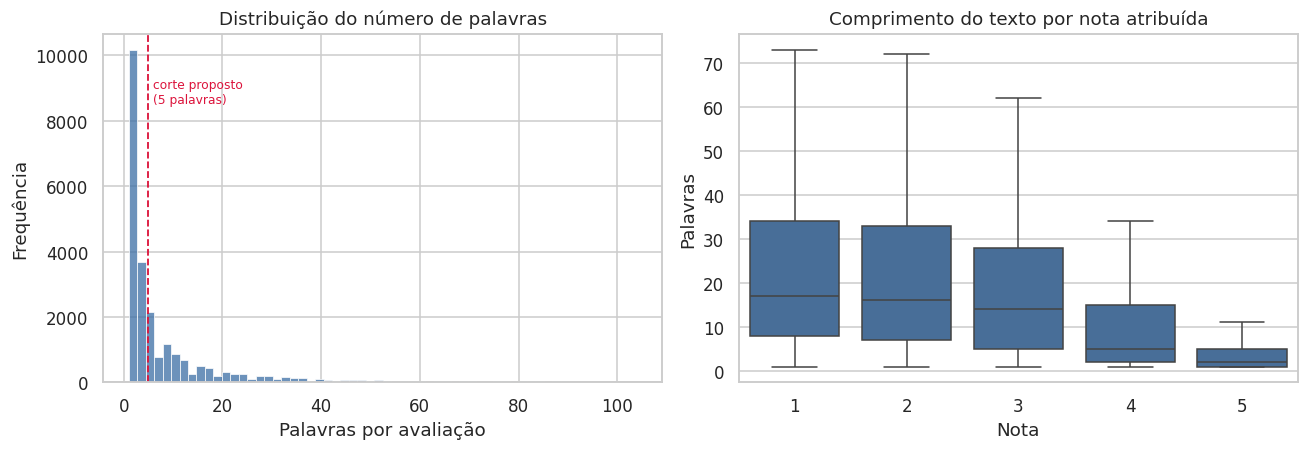

In [9]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(df["n_palavras"], bins=60, ax=eixos[0], color="#3b6ea5")
eixos[0].set_title("Distribuição do número de palavras")
eixos[0].set_xlabel("Palavras por avaliação")
eixos[0].set_ylabel("Frequência")
eixos[0].axvline(5, color="crimson", linestyle="--", linewidth=1.2)
eixos[0].text(6, eixos[0].get_ylim()[1] * 0.8, "corte proposto\n(5 palavras)",
              color="crimson", fontsize=8)

sns.boxplot(data=df, x="nota", y="n_palavras", ax=eixos[1], color="#3b6ea5",
            showfliers=False)
eixos[1].set_title("Comprimento do texto por nota atribuída")
eixos[1].set_xlabel("Nota")
eixos[1].set_ylabel("Palavras")

salvar("02_comprimento_textos.png")

In [10]:
comp_nota = df.groupby("nota")["n_palavras"].agg(
    media="mean", mediana="median", p90=lambda s: s.quantile(0.9), n="size"
).round(2)
comp_nota

,media,mediana,p90,n
nota,,,,
1,24.73,17.0,60.0,3560
2,23.59,16.0,54.1,640
3,19.99,14.0,48.8,773
4,11.70,5.0,31.8,1093
5,5.12,2.0,12.0,17934


Este é um dos achados centrais da exploração. Existe uma relação inversa e
acentuada entre a nota atribuída e a extensão do texto: avaliações negativas são
substancialmente mais longas do que avaliações positivas.

A leitura é intuitiva e tem consequência prática. O usuário satisfeito registra
sua aprovação em duas ou três palavras; o usuário que teve um prejuízo concreto
descreve o ocorrido em detalhe, porque busca resolução. Isso significa que **o
conteúdo informativo do conjunto está concentrado justamente nas avaliações
negativas**, que são as de interesse para este projeto.

## 6. Evolução temporal

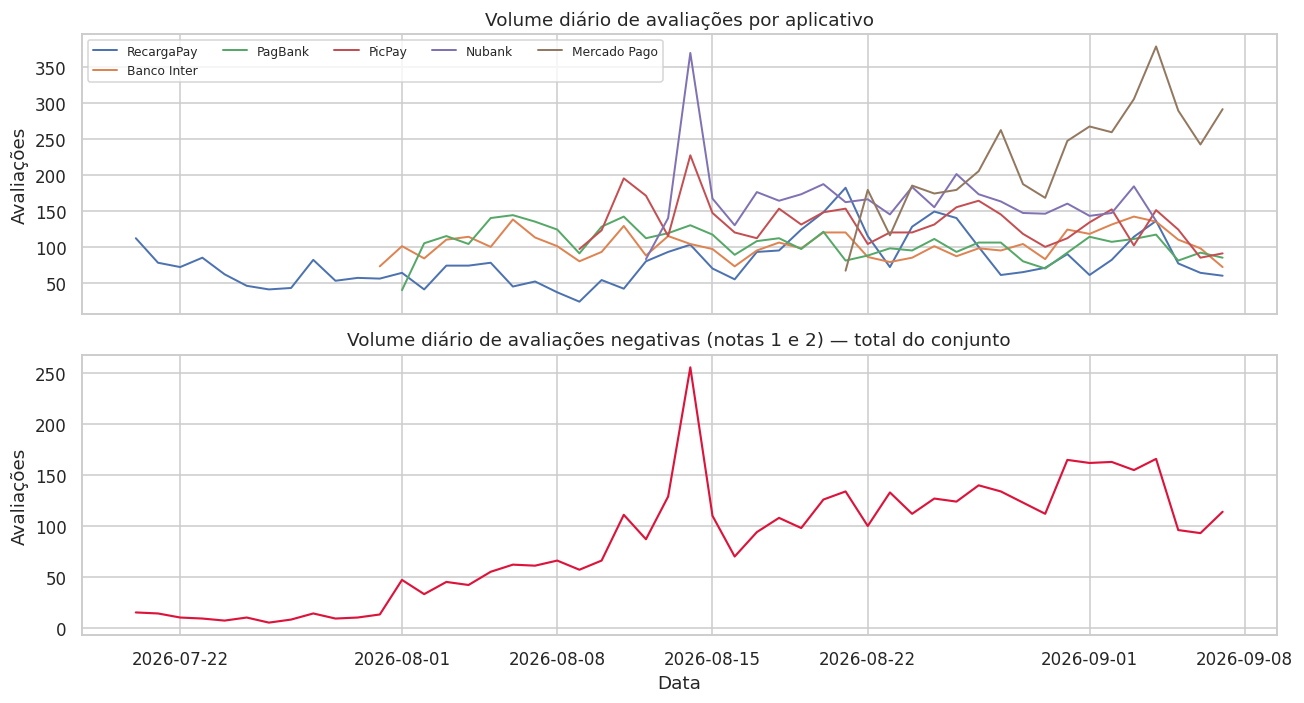

In [11]:
serie = (
    df.set_index("data")
      .groupby([pd.Grouper(freq="D"), "aplicativo"])
      .agg(volume=("nota", "size"), nota_media=("nota", "mean"))
      .reset_index()
)

fig, eixos = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

sns.lineplot(data=serie, x="data", y="volume", hue="aplicativo", ax=eixos[0], linewidth=1.3)
eixos[0].set_title("Volume diário de avaliações por aplicativo")
eixos[0].set_ylabel("Avaliações")
eixos[0].set_xlabel("")
eixos[0].legend(fontsize=8, ncol=5)

negativas = df[df["nota"] <= 2].set_index("data").groupby(pd.Grouper(freq="D")).size()
sns.lineplot(x=negativas.index, y=negativas.values, ax=eixos[1],
             color="crimson", linewidth=1.4)
eixos[1].set_title("Volume diário de avaliações negativas (notas 1 e 2) — total do conjunto")
eixos[1].set_ylabel("Avaliações")
eixos[1].set_xlabel("Data")

salvar("03_evolucao_temporal.png")

In [12]:
janela = df.groupby("aplicativo")["data"].agg(["min", "max"])
janela["dias_cobertos"] = (janela["max"] - janela["min"]).dt.days
janela

,min,max,dias_cobertos
aplicativo,,,
Banco Inter,2026-07-31 14:14:13,2026-09-07 22:45:05,38
Mercado Pago,2026-08-21 17:51:52,2026-09-07 23:05:20,17
Nubank,2026-08-12 15:35:57,2026-09-04 22:26:34,23
PagBank,2026-08-01 17:26:21,2026-09-07 23:00:40,37
PicPay,2026-08-09 00:31:48,2026-09-07 22:45:05,29
RecargaPay,2026-07-20 04:49:45,2026-09-07 23:02:14,49


A janela temporal coberta difere entre aplicativos. Como a captura recuperou um
número fixo de avaliações mais recentes por aplicativo, os que recebem mais
avaliações por dia cobrem um intervalo menor. Trata-se de uma limitação conhecida
do desenho de coleta, que deve ser considerada em qualquer comparação temporal
direta entre aplicativos.

A série de avaliações negativas é o embrião do indicador operacional proposto
como subproduto do projeto: uma vez que o classificador atribua categorias, essa
mesma curva poderá ser decomposta por tipo de problema.

## 7. Análise do vocabulário

In [13]:
STOPWORDS_PT = set("""
a as o os um uma uns umas de do da dos das em no na nos nas por pelo pela para
com sem sob sobre entre ate ate e ou mas porem que se ao aos as e eu tu ele ela
nos vos eles elas me te lhe nos vos lhes meu minha meus minhas teu tua seu sua
seus suas nosso nossa isso isto aquilo esse essa este esta aquele aquela ja mais
menos muito pouco tao tanto todo toda todos todas nada nenhum ninguem algo algum
alguem outro outra outros outras mesmo mesma tambem so apenas ainda quando onde
como porque pois entao assim depois antes agora hoje ontem amanha sempre nunca
nao sim ser estar ter haver fazer ir vir dar ver saber poder querer dizer e
vou vai vao foi fui era eram sao esta estao tem tenho temos tinha teve seja
sendo sido feito fez fica ficou ficar da de la ca aqui ali nele nela pra pro
q pq vc vcs tbm tb ne to ta tao dele dela deles delas
""".split())

def normalizar(texto: str) -> str:
    """Aplica caixa baixa, remove acentos, símbolos e alonga­mentos de caracteres."""
    texto = str(texto).lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(ch for ch in texto if not unicodedata.combining(ch))
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"(.)\1{2,}", r"\1", texto)   # "muitooooo" -> "muito"
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def tokenizar(texto: str) -> list:
    return [t for t in normalizar(texto).split() if t not in STOPWORDS_PT and len(t) > 2]

exemplo = df.loc[df["n_palavras"] > 12, "texto"].iloc[0]
print("ORIGINAL :", exemplo[:180])
print()
print("NORMALIZADO:", normalizar(exemplo)[:180])
print()
print("TOKENS     :", tokenizar(exemplo)[:20])

ORIGINAL : Não consigo recuperar a minha conta no Pic pay pois não tenho o número de telefone e nem o email e o assistente virtual não ajuda sempre volta pedindo para colocar a senha mesmo qu

NORMALIZADO: nao consigo recuperar a minha conta no pic pay pois nao tenho o numero de telefone e nem o email e o assistente virtual nao ajuda sempre volta pedindo para colocar a senha mesmo qu

TOKENS     : ['consigo', 'recuperar', 'conta', 'pic', 'pay', 'numero', 'telefone', 'nem', 'email', 'assistente', 'virtual', 'ajuda', 'volta', 'pedindo', 'colocar', 'senha', 'coloco', 'recuperar', 'senha']


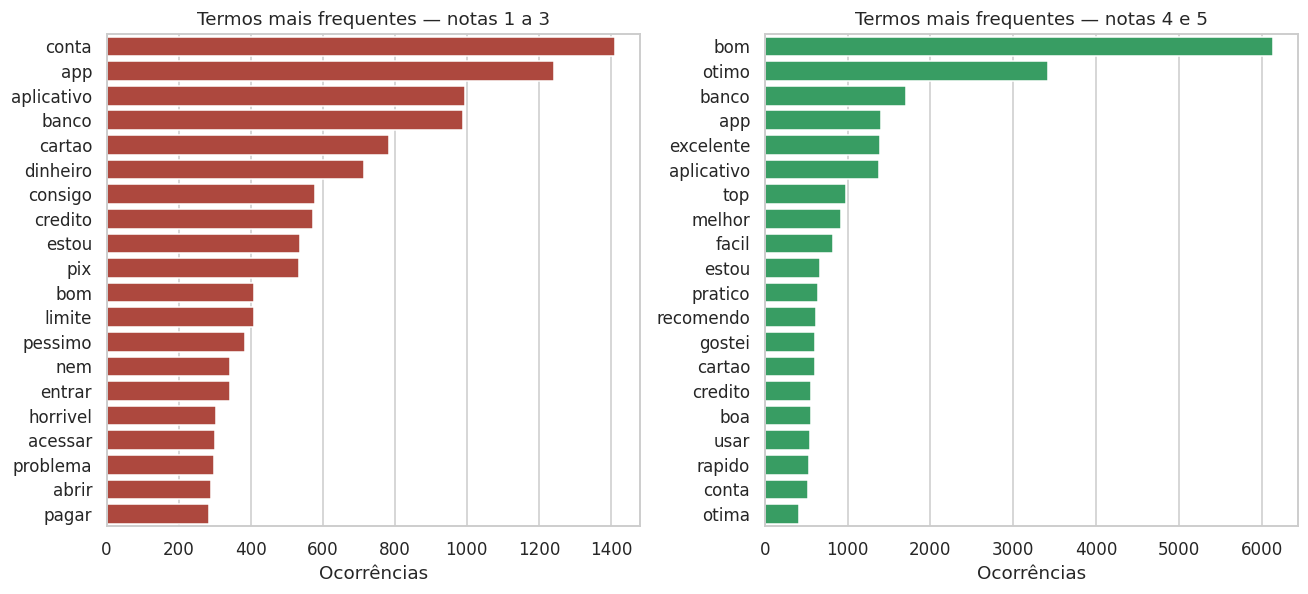

In [14]:
negativos = df[df["nota"] <= 3]
positivos = df[df["nota"] >= 4]

freq_neg = Counter(t for txt in negativos["texto"] for t in tokenizar(txt))
freq_pos = Counter(t for txt in positivos["texto"] for t in tokenizar(txt))

top_neg = pd.DataFrame(freq_neg.most_common(20), columns=["termo", "frequencia"])
top_pos = pd.DataFrame(freq_pos.most_common(20), columns=["termo", "frequencia"])

fig, eixos = plt.subplots(1, 2, figsize=(12, 5.5))
sns.barplot(data=top_neg, y="termo", x="frequencia", ax=eixos[0], color="#c0392b")
eixos[0].set_title("Termos mais frequentes — notas 1 a 3")
eixos[0].set_xlabel("Ocorrências")
eixos[0].set_ylabel("")
sns.barplot(data=top_pos, y="termo", x="frequencia", ax=eixos[1], color="#27ae60")
eixos[1].set_title("Termos mais frequentes — notas 4 e 5")
eixos[1].set_xlabel("Ocorrências")
eixos[1].set_ylabel("")
salvar("04_termos_frequentes.png")

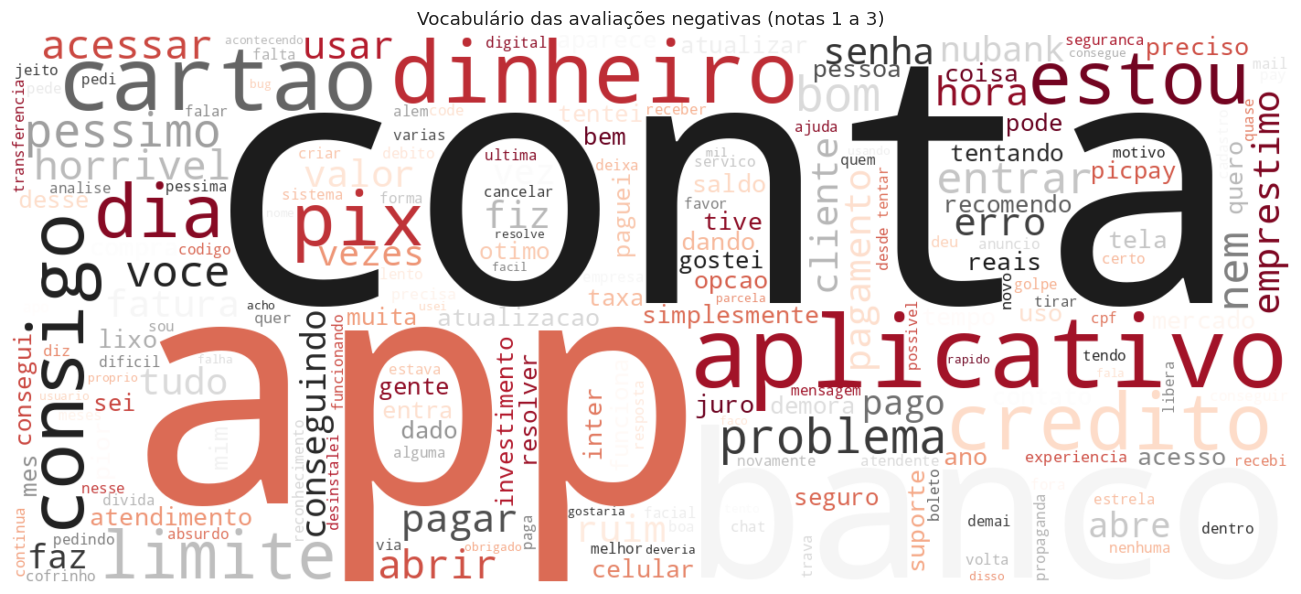

In [15]:
texto_neg = " ".join(normalizar(t) for t in negativos["texto"])
nuvem = WordCloud(
    width=1400, height=600, background_color="white",
    stopwords=STOPWORDS_PT, colormap="RdGy", min_word_length=3,
    collocations=False,
).generate(texto_neg)

plt.figure(figsize=(13, 5.5))
plt.imshow(nuvem, interpolation="bilinear")
plt.axis("off")
plt.title("Vocabulário das avaliações negativas (notas 1 a 3)", fontsize=12)
salvar("05_nuvem_negativas.png")

O vocabulário das avaliações negativas é operacional e concreto: predominam
substantivos ligados a produtos e a ativos financeiros, além de verbos que
descrevem impedimento de uso. Já o vocabulário positivo é avaliativo e genérico,
composto sobretudo por adjetivos de aprovação.

Essa assimetria reforça a decisão metodológica adotada. Os termos negativos
carregam informação suficiente para discriminar **categorias de problema**; os
positivos, não. Um classificador treinado sobre o conjunto completo aprenderia
sobretudo a separar elogio curto de reclamação longa, tarefa trivial e de baixo
valor prático.

## 8. Definição do corpus de modelagem

A exploração conduziu a dois critérios de recorte, aplicados de forma
transparente e reversível.

In [16]:
df["texto_limpo"] = df["texto"].apply(normalizar)
df["n_tokens"] = df["texto_limpo"].apply(lambda t: len(tokenizar(t)))

criterio_nota = df["nota"] <= 3
criterio_tam = df["n_palavras"] >= 5

etapas = pd.DataFrame([
    ("Conjunto capturado", len(df)),
    ("Após filtro de nota (1 a 3)", int(criterio_nota.sum())),
    ("Após filtro de comprimento (>= 5 palavras)", int((criterio_nota & criterio_tam).sum())),
], columns=["Etapa", "Registros"])
etapas["Percentual do original"] = (etapas["Registros"] / len(df) * 100).round(1)
etapas

,Etapa,Registros,Percentual do original
0,Conjunto capturado,24000,100.0
1,Após filtro de nota (1 a 3),4973,20.7
2,Após filtro de comprimento (>= 5 palavras),4211,17.5


**Critério de nota.** O objeto do projeto é a reclamação. Avaliações de quatro e
cinco estrelas são majoritariamente elogios sem descrição de problema e não
contribuem para a tarefa de categorização.

**Critério de comprimento.** Textos com menos de cinco palavras não contêm
elementos suficientes para identificar a natureza do problema. Uma avaliação de
uma estrela composta apenas por "péssimo" é insatisfação sem diagnóstico.

Os registros excluídos **não são descartados**: permanecem no conjunto publicado e
sustentam a caracterização do fenômeno apresentada nas seções anteriores. O
recorte se aplica exclusivamente à etapa de modelagem.

In [17]:
corpus = df[criterio_nota & criterio_tam].copy().reset_index(drop=True)

stemmer = SnowballStemmer("portuguese")
corpus["tokens"] = corpus["texto_limpo"].apply(tokenizar)
corpus["texto_processado"] = corpus["tokens"].apply(
    lambda ts: " ".join(stemmer.stem(t) for t in ts)
)

print(f"Corpus de modelagem: {len(corpus):,} avaliações".replace(",", "."))
print()
print("Composição por aplicativo e nota:")
display(pd.crosstab(corpus["aplicativo"], corpus["nota"], margins=True, margins_name="Total"))
print()
print("Exemplo de processamento completo:")
linha = corpus.iloc[3]
print(" original  :", linha["texto"][:150])
print(" processado:", linha["texto_processado"][:150])

Corpus de modelagem: 4.211 avaliações

Composição por aplicativo e nota:


nota,1,2,3,Total
aplicativo,,,,
Banco Inter,693,129,133,955
Mercado Pago,362,71,78,511
Nubank,623,132,155,910
PagBank,399,78,78,555
PicPay,555,77,76,708
RecargaPay,426,68,78,572
Total,3058,555,598,4211



Exemplo de processamento completo:
 original  : Estarei encerando a minha conta depois de 7 anos de ser aberta. O motivo?! A instituição financeira tem colocado anúncios de casas de aposta dentro do
 processado: estar encer cont anos abert motiv instituica financeir coloc anunci cas apost dentr app mim ultrapass limit instituica milh milho brasileir usam diari


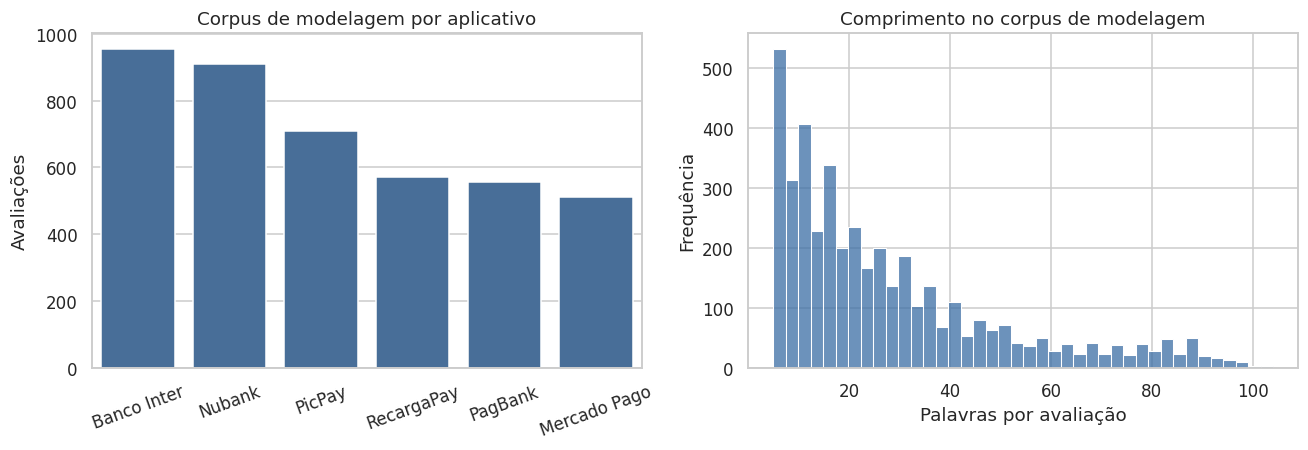

In [18]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.2))
sns.countplot(data=corpus, x="aplicativo", ax=eixos[0], color="#3b6ea5",
              order=corpus["aplicativo"].value_counts().index)
eixos[0].set_title("Corpus de modelagem por aplicativo")
eixos[0].set_xlabel("")
eixos[0].set_ylabel("Avaliações")
eixos[0].tick_params(axis="x", rotation=20)

sns.histplot(corpus["n_palavras"], bins=40, ax=eixos[1], color="#3b6ea5")
eixos[1].set_title("Comprimento no corpus de modelagem")
eixos[1].set_xlabel("Palavras por avaliação")
eixos[1].set_ylabel("Frequência")
salvar("06_corpus_modelagem.png")

## 9. Amostra para rotulagem manual

O conjunto não possui rótulo de categoria na origem. A etapa seguinte do projeto
exige rotulagem manual, realizada pelos integrantes do grupo segundo o esquema de
categorias definido no relatório.

A amostra é estratificada por aplicativo e nota, de modo a preservar a
diversidade de contextos, e dimensionada para ser exequível por três anotadores.
Um subconjunto é marcado para rotulagem em duplicata, permitindo mensurar a
concordância entre anotadores.

In [19]:
TAMANHO_AMOSTRA = 1200
SEMENTE = 42

fracao = TAMANHO_AMOSTRA / len(corpus)
amostra = (
    corpus.groupby(["aplicativo", "nota"], group_keys=False)
          .sample(frac=fracao, random_state=SEMENTE)
          .reset_index(drop=True)
)

amostra["anotador"] = [["Bruno", "Vinicius", "Gabriel"][i % 3] for i in range(len(amostra))]
amostra["dupla_checagem"] = 0
amostra.loc[amostra.sample(frac=0.10, random_state=SEMENTE).index, "dupla_checagem"] = 1
amostra["categoria"] = ""

print(f"Amostra para rotulagem: {len(amostra):,} avaliações".replace(",", "."))
print(f"Marcadas para dupla checagem: {int(amostra['dupla_checagem'].sum())}")
print()
print(amostra.groupby("anotador").size())
print()
display(pd.crosstab(amostra["aplicativo"], amostra["nota"], margins=True, margins_name="Total"))

Amostra para rotulagem: 1.199 avaliações
Marcadas para dupla checagem: 120

anotador
Bruno       400
Gabriel     399
Vinicius    400
dtype: int64



nota,1,2,3,Total
aplicativo,,,,
Banco Inter,197,37,38,272
Mercado Pago,103,20,22,145
Nubank,178,38,44,260
PagBank,114,22,22,158
PicPay,158,22,22,202
RecargaPay,121,19,22,162
Total,871,158,170,1199


## 10. Exportação dos artefatos

In [20]:
colunas_corpus = [
    "id_avaliacao", "aplicativo", "usuario_pseudonimizado", "nota", "texto",
    "texto_limpo", "texto_processado", "n_palavras", "n_tokens", "data",
    "curtidas", "versao_app",
]
colunas_amostra = [
    "id_avaliacao", "aplicativo", "nota", "texto", "anotador",
    "dupla_checagem", "categoria",
]

saida_corpus = os.path.join(PASTA_DADOS, "corpus_modelagem.csv")
saida_amostra = os.path.join(PASTA_DADOS, "amostra_rotulagem.csv")

corpus[colunas_corpus].to_csv(saida_corpus, index=False, encoding="utf-8-sig")
amostra[colunas_amostra].to_csv(saida_amostra, index=False, encoding="utf-8-sig")

print("Arquivos gerados:")
for caminho in (saida_corpus, saida_amostra):
    print(f"  {caminho}  ({os.path.getsize(caminho)/1024:.1f} KB)")
print()
print("Figuras geradas:")
for arquivo in sorted(os.listdir(PASTA_FIG)):
    print("  ", os.path.join(PASTA_FIG, arquivo))

Arquivos gerados:
  dados/corpus_modelagem.csv  (2031.2 KB)
  dados/amostra_rotulagem.csv  (258.6 KB)

Figuras geradas:
   figuras/01_distribuicao_notas.png
   figuras/02_comprimento_textos.png
   figuras/03_evolucao_temporal.png
   figuras/04_termos_frequentes.png
   figuras/05_nuvem_negativas.png
   figuras/06_corpus_modelagem.png


## 11. Síntese da análise exploratória

1. O conjunto capturado é íntegro: não há identificadores duplicados, textos
   vazios ou notas fora do intervalo válido. A única ausência relevante está no
   campo de versão do aplicativo, cuja indisponibilidade é característica da
   plataforma de origem e não compromete a análise.

2. A distribuição das notas é fortemente assimétrica, com predominância das
   avaliações máximas e escassez das notas intermediárias. Isso inviabiliza o uso
   da nota como rótulo substituto e recomenda métricas por classe na etapa de
   modelagem.

3. Existe relação inversa entre nota e extensão do texto. A informação
   diagnóstica do conjunto concentra-se nas avaliações negativas, o que sustenta
   o recorte adotado para o corpus de modelagem.

4. O vocabulário negativo é concreto e operacional, ao passo que o positivo é
   genérico e avaliativo — evidência de que há sinal suficiente para discriminar
   categorias de problema no recorte selecionado.

5. A política de resposta pública varia drasticamente entre empresas, o que
   caracteriza esse campo como indicador de comunicação corporativa e justifica
   sua exclusão do conjunto de atributos preditivos.

6. O corpus de modelagem e a amostra estratificada para rotulagem manual foram
   gerados e exportados, deixando o projeto pronto para a etapa de anotação e
   treinamento prevista para o segundo bimestre.
